In [1]:
import sys
sys.path.append('..') 
from model_architectures import *
from sklearn.model_selection import train_test_split
import torch.optim as optim
# from torch.optim.lr_scheduler import StepLR, OneCycleLR
from collections import Counter
import torch.optim as optim
from torch.nn import CrossEntropyLoss

C:\Users\Sai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# Enable GPU usage for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
batch_size = 50
dataset = ImageTextDataset(image_dir='../Sanrio/images', text_dir='../Sanrio/text', transform=image_transform, tokenizer=tokenizer)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

In [4]:
src_vocab_size = len(tokenizer)
tgt_vocab_size = len(tokenizer)
d_model = 320
num_heads = 8
num_layers = 6
d_ff = 2048
max_seq_length = 1000
dropout = 0.1

In [5]:
model = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout, device=device)
model = model.to(device)

criterion = CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

C:\Users\Sai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Sai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
num_epochs = 1
losses = []

for epoch in range(num_epochs):
    model.train()
    counter = 0
    epoch_loss = 0
    for images, input_ids, attention_mask in dataloader:
        counter += 1
        print(f"Epoch {epoch+1}, Batch: [{counter}/{len(dataloader)}]")
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        tgt_input = input_ids[:, :-1]
        tgt_output = input_ids[:, 1:]

        optimizer.zero_grad()

        output = model(images, tgt_input)

        # Assuming `output` is the model's output and `tgt_output` is the target output
        output = output.reshape(-1, output.size(-1))  # Reshape to (N, C)
        tgt_output = tgt_output.reshape(-1)  # Reshape to (N,)

        # Compute the loss
        loss = criterion(output, tgt_output)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_epoch_loss = epoch_loss / len(dataloader)
    losses.append(average_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {average_epoch_loss}")


Epoch 1, Batch: [1/10]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (50x2048 and 320x320)

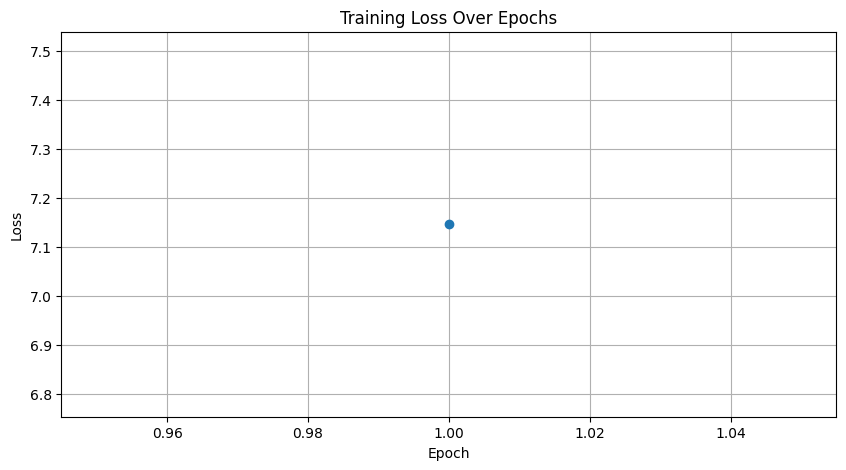

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid()
plt.show()

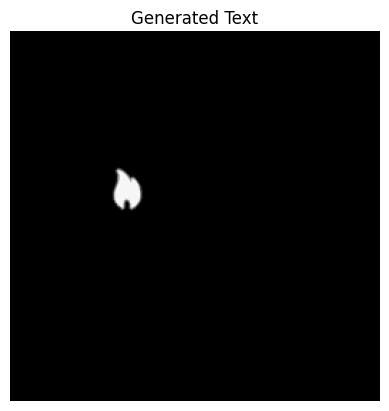

Generated Text: ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [ ]:
def generate_text_for_image(image_path, model, tokenizer, device, max_seq_length=50):
    model.eval()
    
    image = Image.open(image_path).convert("RGB")
    image = image_transform(image).unsqueeze(0).to(device)  # Apply the same transform used for training
    generated_text = []

    with torch.no_grad():
        input_ids = torch.tensor([tokenizer.cls_token_id], device=device).unsqueeze(0)  # Start with the CLS token
        for _ in range(1000):
            outputs = model(image, input_ids)
            next_token_id = torch.argmax(outputs[:, -1, :], dim=-1).item()
            if next_token_id == tokenizer.sep_token_id:
                break
            generated_text.append(next_token_id)
            input_ids = torch.cat([input_ids, torch.tensor([[next_token_id]], device=device)], dim=-1)

    generated_text = tokenizer.decode(generated_text)
    return image, generated_text

# %%
# Load an image from another directory and generate text for it
image_path = '../Logos/images/zippo-logo-01.png'
image, generated_text = generate_text_for_image(image_path, model, tokenizer, device)

# Display the image and print the generated text
plt.imshow(np.array(image.cpu().squeeze()), cmap = "gray")
plt.axis('off')
plt.title("Generated Text")
plt.show()
print("Generated Text:", generated_text)